1. Dataset Description

Dataset: Breast Cancer Wisconsin (Diagnostic) Dataset

This dataset contains features computed from digitized images of fine needle aspirate (FNA) of breast masses.

Number of samples: 569
Number of features: 30 (continuous numerical features)
Target classes:

0 → Malignant

1 → Benign

Since the features are continuous and approximately normally distributed, Gaussian Naïve Bayes is the appropriate variant.

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset and ML
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report


In [ ]:
#Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)
print("Target classes:", data.target_names)

X.head()


Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


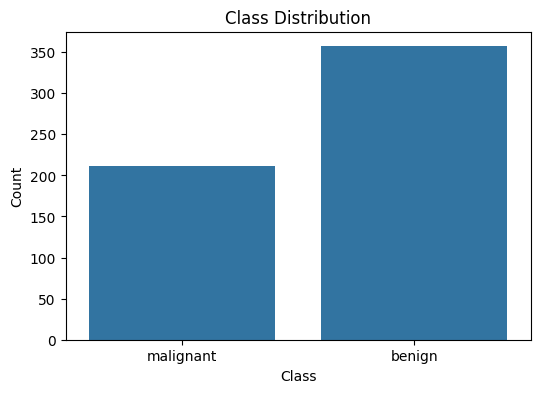

In [ ]:
#Exploratory Data Analysis & Visualization
# class distribution

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.xticks([0,1], data.target_names)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# To Confirm whether dataset is balanced

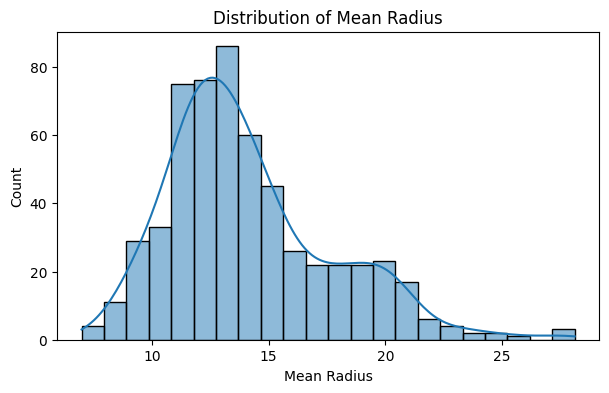

In [ ]:
#Feature Distribution (Gaussian Assumption)
plt.figure(figsize=(7,4))
sns.histplot(X['mean radius'], kde=True)
plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.show()

# Justifies Gaussian Naïve Bayes

In [ ]:
#Data Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#Train Naïve Bayes Model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_nb = gnb.predict(X_test)

In [ ]:
#Evaluation Metrics (Naïve Bayes)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naïve Bayes Performance:")
print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1-score:", f1_nb)

Naïve Bayes Performance:
Accuracy: 0.9298245614035088
Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1-score: 0.9444444444444444


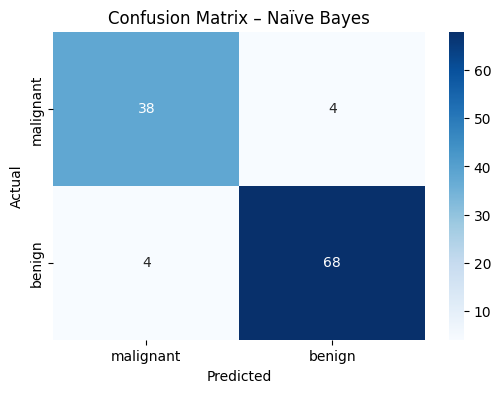

In [ ]:
#Confusion Matrix Visualization
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Naïve Bayes")
plt.show()

In [ ]:
#Classification Report
print(classification_report(y_test, y_pred_nb, target_names=data.target_names))


              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



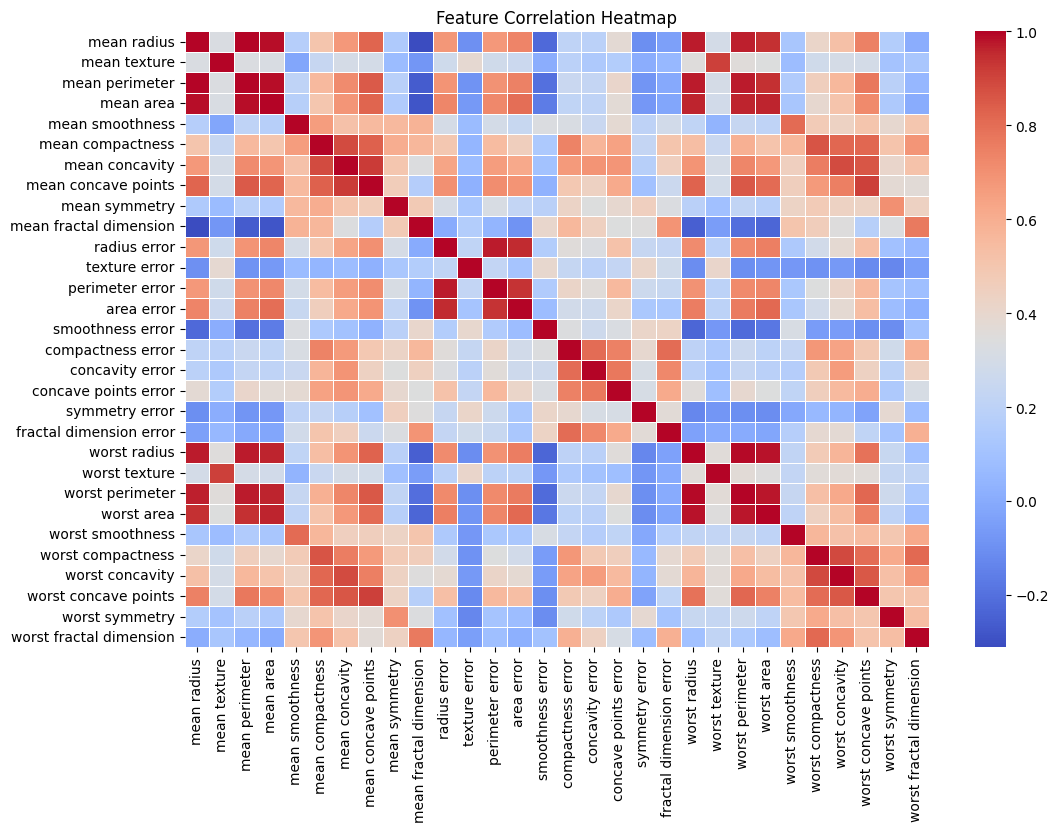

In [ ]:
# Feature Correlation Heatmap (Limitation Visualization)
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm', linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.show()

#Supports discussion about feature independence assumption

In [ ]:
#Model Comparison – Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

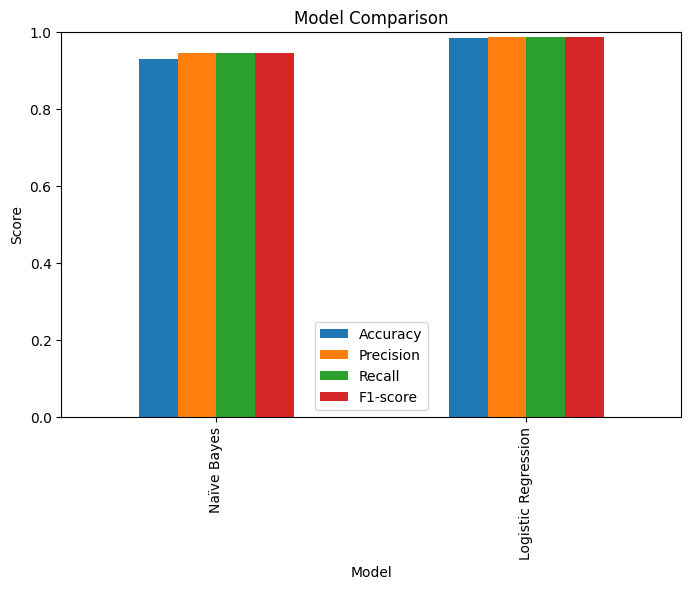

In [ ]:
#Compare Metrics Visually
comparison_df = pd.DataFrame({
    "Model": ["Naïve Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_nb, accuracy_lr],
    "Precision": [precision_nb, precision_lr],
    "Recall": [recall_nb, recall_lr],
    "F1-score": [f1_nb, f1_lr]
})

comparison_df

comparison_df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.ylim(0,1)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

Discussion of Results

Discussion:
Gaussian Naïve Bayes achieved high accuracy despite the strong correlation between features.
This confirms that Naïve Bayes performs well as a baseline classifier even when its independence assumption is violated.
Logistic Regression achieved slightly higher performance, as it can better model feature relationships.
However, Naïve Bayes remains computationally efficient and easy to interpret.